## Data Generation

Imports

In [1]:
import pybamm
import numpy as np
from scipy.stats import qmc
#import warnings

Virtual cell design

In [ ]:
param_li = pybamm.ParameterValues("Chen2020")       # "Target geometry" (Commercial 21700 Cell, 5Ah)
param_na = pybamm.ParameterValues("Chayambuka2022") # Sodium chemistry (Hard Carbon / NVPF)

# Explicitly set the voltage cut-off for the Sodium cell to 2 Volts
param_na["Lower voltage cut-off [V]"] = 2   # Default, but we set it explicitly for clarity

# List of macro-geometric parameters to copy from Lithium to Sodium
# to ensure a rigorous iso-geometric comparison (Sulzer et al., 2021)
macro_parameters = [
    "Nominal cell capacity [A.h]",
    "Electrode height [m]",
    "Electrode width [m]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Positive electrode thickness [m]",
    "Number of electrodes connected in parallel to make a cell",
    "Cell volume [m3]",
    "Cell cooling surface area [m2]"
]

# Overwrite the coin cell geometry with the commercial cell geometry
for p in macro_parameters:
    param_na[p] = param_li[p]

# Tell PyBaMM which parameters will be input (Current and Diffusivity)
param_na["Current function [A]"] = "[input]"
param_na["Negative electrode diffusivity [m2.s-1]"] = "[input]" # Anode (Hard Carbon)
param_na["Positive electrode diffusivity [m2.s-1]"] = "[input]" # Cathode (NVPF)
param_na["Electrolyte diffusivity [m2.s-1]"] = "[input]"        # Liquid Electrolyte

# We want a total of 64 spatial nodes across the x-axis (21 + 20 + 21 = 62, plus 2 for the boundaries = 64)
# This is done because powers of 2 (like 64) are highly optimized for Fast Fourier Transforms in PyTorch
var_pts = {
    "x_n": 21,  # negative electrode (anode)
    "x_s": 20,  # separator
    "x_p": 21,  # positive electrode (cathode)
    "r_n": 10,  # particle radius (internal, not outputted to FNO)
    "r_p": 10   
}

# We treat PyBaMM numerical warnings as actual errors to discard unstable simulations
# warnings.filterwarnings("error", category=pybamm.SolverWarning) #Disabled, too severe currently

# Load the DFN/P2D model for Sodium with the new scaled parameters
model = pybamm.sodium_ion.BasicDFN()
sim = pybamm.Simulation(model, parameter_values=param_na, var_pts=var_pts, solver=pybamm.CasadiSolver(mode="safe")) # 'safe' suggested for full charge/discharge simulations
t_eval_max = [0, 40000] # Time limit

Visualize the cell parameters

In [5]:
print("\n" + "="*60)
print("   VIRTUAL CELL DESIGN: FINAL PARAMETERS OVERVIEW")
print("="*60)

keys_to_print = [
    "Nominal cell capacity [A.h]",
    "Lower voltage cut-off [V]",
    "Cell volume [m3]",
    "Cell cooling surface area [m2]",
    "Negative electrode thickness [m]",
    "Separator thickness [m]",
    "Positive electrode thickness [m]",
    "Negative electrode porosity",
    "Positive electrode porosity",
    "Negative particle radius [m]",
    "Positive particle radius [m]"
]

print(f"{'Parameter':<40} | {'Value'}")
print("-" * 60)
for key in keys_to_print:
    val = param_na[key]
    # Scientific notation for small values
    if isinstance(val, (int, float)):
        val_str = f"{val:.4e}" if val < 0.01 else f"{val:.4f}"
    else:
        val_str = str(val)
    print(f"{key:<40} | {val_str}")
print("="*60 + "\n")


   VIRTUAL CELL DESIGN: FINAL PARAMETERS OVERVIEW
Parameter                                | Value
------------------------------------------------------------
Nominal cell capacity [A.h]              | 5.0000
Lower voltage cut-off [V]                | 2.0000
Cell volume [m3]                         | 2.4200e-05
Cell cooling surface area [m2]           | 5.3100e-03
Negative electrode thickness [m]         | 8.5200e-05
Separator thickness [m]                  | 1.2000e-05
Positive electrode thickness [m]         | 7.5600e-05
Negative electrode porosity              | 0.5100
Positive electrode porosity              | 0.2300
Negative particle radius [m]             | 3.4800e-06
Positive particle radius [m]             | 5.9000e-07



LATIN HYPERCUBE SAMPLING (LHS)

In [7]:
# HYPERPARAMETERS for the LHS sampling of the input space
TARGET_SAMPLES = 500
POOL_SIZE = 3000    # Number of random samples to generate each time
num_parameters = 4  # Current, Anode/Cathode/Electrolyte Diffusivity
RANDOM_SEED = 42

sampler = qmc.LatinHypercube(d=num_parameters, seed=RANDOM_SEED)
raw_samples = sampler.random(n=POOL_SIZE)

# Parameter 1: Current [A] (0.5 to 5.0)
I_min, I_max = 0.5, 5.0 # Amperes
I_lhs = I_min + raw_samples[:, 0] * (I_max - I_min)

# Parameter 2: Anode Diffusivity [m2/s] (Log scale 1e-16 to 1e-14)
Ds_n_lhs = 10 ** (-16.0 + raw_samples[:, 1] * 2.0)

# Parameter 3: Cathode Diffusivity [m2/s] (Log scale 1e-16 to 1e-14)
Ds_p_lhs = 10 ** (-16.0 + raw_samples[:, 2] * 2.0)

# Parameter 4: Electrolyte Diffusivity [m2/s] (Log scale 1e-11 to 1e-9)
De_lhs = 10 ** (-11.0 + raw_samples[:, 3] * 2.0)

X_pool = np.column_stack((I_lhs, Ds_n_lhs, Ds_p_lhs, De_lhs))

Simulation Loop for the Dataset

In [8]:
dataset_y = []       
valid_inputs = []
durations = [] # For analyzing it later

print(f"Beginning simulations... (The process will stop once {TARGET_SAMPLES} valid samples are extracted)")

for i in range(POOL_SIZE):
    # Stop if we have reached the target number of valid samples
    if len(valid_inputs) == TARGET_SAMPLES:
        print(f"\n TARGET REACHED: {TARGET_SAMPLES} valid simulations extracted!")
        break
        
    try:
        sim.solve(
            t_eval=t_eval_max, 
            inputs={
                "Current function [A]": X_pool[i, 0],
                "Negative electrode diffusivity [m2.s-1]": X_pool[i, 1],
                "Positive electrode diffusivity [m2.s-1]": X_pool[i, 2],
                "Electrolyte diffusivity [m2.s-1]": X_pool[i, 3]
            }
        )
        
        t_max = sim.solution["Time [s]"].entries[-1]    # Extract the actual final time before the voltage cut-off
        if t_max < 1.0:
            continue    # We discard simulations that failed instantly (i.e. lasted less than 1 second)

        t_eval_uniform = np.linspace(0, t_max, 100)     # Temporal Normalization (100 uniform snapshots from start to finish)  
        
        # Spatial map extraction for Electrolyte Concentration
        c_e_obj = sim.solution["Electrolyte concentration [mol.m-3]"]
        c_e_uniform = c_e_obj(t=t_eval_uniform) # Shape will now be (64, 100)
        
        # Store successful data
        dataset_y.append(c_e_uniform)
        valid_inputs.append(X_pool[i])
        durations.append(t_max)
        
        if (len(valid_inputs)) % 25 == 0: 
            print(f"Progress: {len(valid_inputs)} valid simulations extracted...")
            
    except Exception as e:
        pass    # Ignore simulations that cause errors

Beginning simulations... (The process will stop once 500 valid samples are extracted)


At t = 399.581, , mxstep steps taken before reaching tout.
At t = 99.5813, , mxstep steps taken before reaching tout.
At t = 99.5813, , mxstep steps taken before reaching tout.
At t = 24.5813, , mxstep steps taken before reaching tout.
At t = 24.5813, , mxstep steps taken before reaching tout.
At t = 85.0962, , mxstep steps taken before reaching tout.
At t = 85.0962, , mxstep steps taken before reaching tout.
At t = 85.0964, , mxstep steps taken before reaching tout.
At t = 23.2143 and h = 1.17473e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 23.2266 and h = 8.67109e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 23.2445 and h = 1.94211e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 23.244 and h = 2.22607e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 23.2424 and h = 1.64193e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 4.49532 and h = 1.6964

Progress: 25 valid simulations extracted...


At t = 87.0561 and h = 4.37503e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 87.031 and h = 6.80782e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 87.1087 and h = 4.76782e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 12.0864 and h = 6.56003e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 12.0885 and h = 5.97224e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 12.0908 and h = 7.54649e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 2.69767 and h = 9.67202e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 2.69421 and h = 4.07839e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.445194 and h = 5.62288e-10, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 0.419296 and h = 3.28759e-09, the corrector convergence failed repeatedly or with |h| = hmin.

Progress: 50 valid simulations extracted...


...

At t = 297.005, , mxstep steps taken before reaching tout.
At t = 297.004, , mxstep steps taken before reaching tout.
At t = 147.005, , mxstep steps taken before reaching tout.
At t = 72.0049, , mxstep steps taken before reaching tout.
At t = 34.505, , mxstep steps taken before reaching tout.
At t = 15.755, , mxstep steps taken before reaching tout.
At t = 187.846 and h = 5.81145e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 187.391 and h = 5.10408e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 37.3999 and h = 2.38556e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 37.5801 and h = 2.97695e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 37.3617 and h = 1.88243e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 37.4032 and h = 1.47557e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 37.4994 and h = 5.8894e-10, the corrector

Progress: 475 valid simulations extracted...


At t = 246.113, , mxstep steps taken before reaching tout.
At t = 246.112, , mxstep steps taken before reaching tout.
At t = 96.1121, , mxstep steps taken before reaching tout.
At t = 21.112, , mxstep steps taken before reaching tout.
At t = 21.112, , mxstep steps taken before reaching tout.
At t = 167.683 and h = 1.68874e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 167.42 and h = 7.07937e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 17.6792 and h = 7.96058e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 17.6807 and h = 1.01771e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 17.6938 and h = 8.57603e-09, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 16.5828 and h = 1.39131e-07, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 17.647 and h = 3.22489e-08, the corrector convergence failed repeatedly or with |h| = hmin.
At t = 17

Progress: 500 valid simulations extracted...

 TARGET REACHED: 500 valid simulations extracted!


At t = 89.7187, , mxstep steps taken before reaching tout.


Save dataset and print info

In [ ]:
X_final = np.array(valid_inputs)
Y_final = np.array(dataset_y)
T_final = np.array(durations)

print("\n" + "="*50)
print("   DATASET SUCCESSFULLY GENERATED")
print("="*50)
print(f"Target valid simulations requested: {TARGET_SAMPLES}")
print(f"Total simulations attempted by LHS: {i + 1}")
print(f"Valid stable simulations stored: {X_final.shape[0]}")
print(f"Discarded due to numerical instability: {(i + 1) - X_final.shape[0]}")
print(f"X Matrix Shape [N, Parameters]: {X_final.shape}")
print(f"Y Tensor Shape [N, Space, Time]: {Y_final.shape}")
print("="*50)

dataset_filename = 'dataset_sodium.npz'
np.savez_compressed(    # Dataset structure
    dataset_filename, 
    X=X_final, # Input parameters (Current, Anode/Cathode/Electrolyte Diffusivity)
    Y=Y_final, # Objective variable (Electrolyte Concentration maps across space and time)
    T=T_final  # Extra file for stats (discharge durations before cut-off)
)
print(f"\nUnified Dataset successfully saved as '{dataset_filename}'.")


   DATASET SUCCESSFULLY GENERATED
Target valid simulations requested: 500
Total simulations attempted by LHS: 1793
Valid stable simulations stored: 500
Discarded due to numerical instability: 1293
X Matrix Shape [N, Parameters]: (500, 4)
Y Tensor Shape [N, Space, Time]: (500, 66, 100)

Files 'X_inputs_sodium.npy', 'Y_outputs_sodium.npy' and 'T_durations_sodium.npy' saved.


## Data Normalization

Statistical analysis

In [2]:
dataset = np.load('dataset_sodium.npz')
X_raw = dataset['X']          # Shape: (N, 4)
Y_raw = dataset['Y']          # Shape: (N, 66, 100)
T_raw = dataset['T']          # Shape: (N,)

num_samples = X_raw.shape[0]

print("="*60)
print("   RAW DATASET STATISTICS (BEFORE NORMALIZATION)")
print("="*60)

param_names = [
    "Current [A]", 
    "Anode Diffusivity [m2/s]", 
    "Cathode Diffusivity [m2/s]", 
    "Electrolyte Diffusivity [m2/s]"
]

for i in range(4):
    data = X_raw[:, i]
    print(f"--- {param_names[i]} ---")
    print(f"  Min:      {np.min(data):.4e}")
    print(f"  Max:      {np.max(data):.4e}")
    print(f"  Mean:     {np.mean(data):.4e}")
    print(f"  Median:   {np.median(data):.4e}")
    print(f"  Variance: {np.var(data):.4e}\n")

print(f"--- Output Y (Concentration [mol/m3]) ---")
print(f"  Global Min: {np.min(Y_raw):.4e}")
print(f"  Global Max: {np.max(Y_raw):.4e}\n")

   RAW DATASET STATISTICS (BEFORE NORMALIZATION)
--- Current [A] ---
  Min:      5.0344e-01
  Max:      4.9999e+00
  Mean:     3.4726e+00
  Median:   3.8568e+00
  Variance: 1.6501e+00

--- Anode Diffusivity [m2/s] ---
  Min:      1.0014e-16
  Max:      9.9751e-15
  Mean:     2.2088e-15
  Median:   1.1670e-15
  Variance: 6.1557e-30

--- Cathode Diffusivity [m2/s] ---
  Min:      1.0015e-16
  Max:      9.8686e-15
  Mean:     1.9724e-15
  Median:   9.0372e-16
  Variance: 5.3773e-30

--- Electrolyte Diffusivity [m2/s] ---
  Min:      1.6903e-11
  Max:      9.9204e-10
  Mean:     2.7745e-10
  Median:   1.8165e-10
  Variance: 5.8862e-20

--- Output Y (Concentration [mol/m3]) ---
  Global Min: -1.7471e+01
  Global Max: 1.3780e+03



Normalization

In [4]:
print("Normalizing features to [0, 1] range...")
X_norm = np.zeros_like(X_raw)

# Feature 0: Current (Linear scale)
I_min, I_max = X_raw[:, 0].min(), X_raw[:, 0].max()
X_norm[:, 0] = (X_raw[:, 0] - I_min) / (I_max - I_min)

# Feature 1: Anode Diffusivity (Logarithmic scale)
Da_log = np.log10(X_raw[:, 1])
Da_min, Da_max = Da_log.min(), Da_log.max()
X_norm[:, 1] = (Da_log - Da_min) / (Da_max - Da_min)

# Feature 2: Cathode Diffusivity (Logarithmic scale)
Dc_log = np.log10(X_raw[:, 2])
Dc_min, Dc_max = Dc_log.min(), Dc_log.max()
X_norm[:, 2] = (Dc_log - Dc_min) / (Dc_max - Dc_min)

# Feature 3: Electrolyte Diffusivity (Logarithmic scale)
De_log = np.log10(X_raw[:, 3])
De_min, De_max = De_log.min(), De_log.max()
X_norm[:, 3] = (De_log - De_min) / (De_max - De_min)

# Output Y: Electrolyte Concentration (Linear scale)
# We'll find the global min and max across the entire 3D tensor to normalize it properly
Y_min, Y_max = Y_raw.min(), Y_raw.max()
Y_norm = (Y_raw - Y_min) / (Y_max - Y_min)
print("NORMALIZATION COMPLETE")

Normalizing features to [0, 1] range...
NORMALIZATION COMPLETE


Verification and dataset saving

In [6]:
print("="*60)
print("   NORMALIZATION CHECK")
print("="*60)
print(f"X Tensor -> Min: {X_norm.min():.2f}, Max: {X_norm.max():.2f}")
print(f"Y Tensor -> Min: {Y_norm.min():.2f}, Max: {Y_norm.max():.2f}")
if np.isnan(X_norm).any() or np.isnan(Y_norm).any():
    print("WARNING: NaNs detected in normalized tensors!")
else:
    print("Check Passed: Tensors are clean and strictly bound between 0 and 1.")

# Save the normalized dataset using .npz to keep it unified
normalized_filename = 'dataset_sodium_normalized.npz'
np.savez_compressed(
    normalized_filename, 
    X_norm=X_norm, 
    Y_norm=Y_norm, 
    T_raw=T_raw, # We keep durations raw for analysis (they are not FNO inputs)
    
    # SALVIAMO ANCHE I VALORI DI SCALATURA (Cruciale per il futuro!)
    scaling_factors=np.array([I_min, I_max, Da_min, Da_max, Dc_min, Dc_max, De_min, De_max, Y_min, Y_max])
)

print(f"\nNormalized dataset and scaling factors saved to '{normalized_filename}'.")

   NORMALIZATION CHECK
X Tensor -> Min: 0.00, Max: 1.00
Y Tensor -> Min: 0.00, Max: 1.00
Check Passed: Tensors are clean and strictly bound between 0 and 1.

Normalized dataset and scaling factors saved to 'dataset_sodium_normalized.npz'.


## Visualization

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

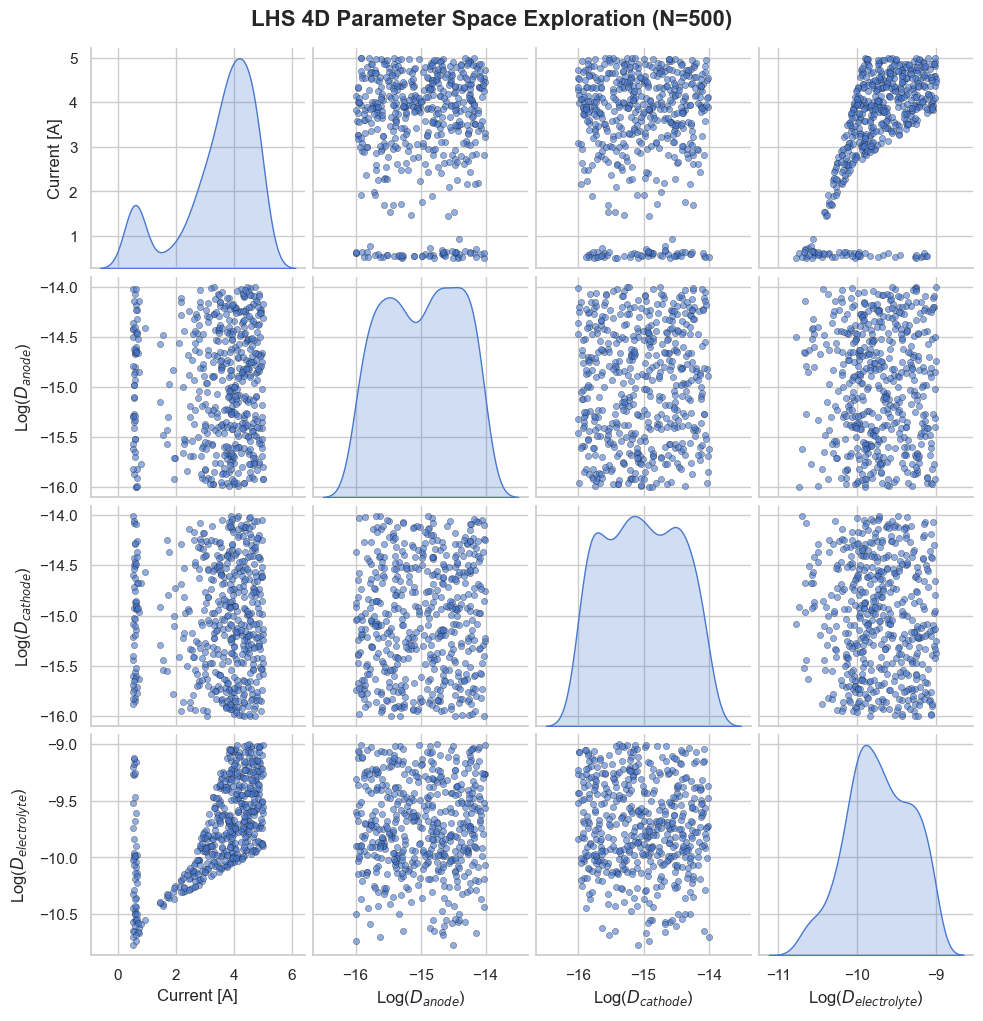

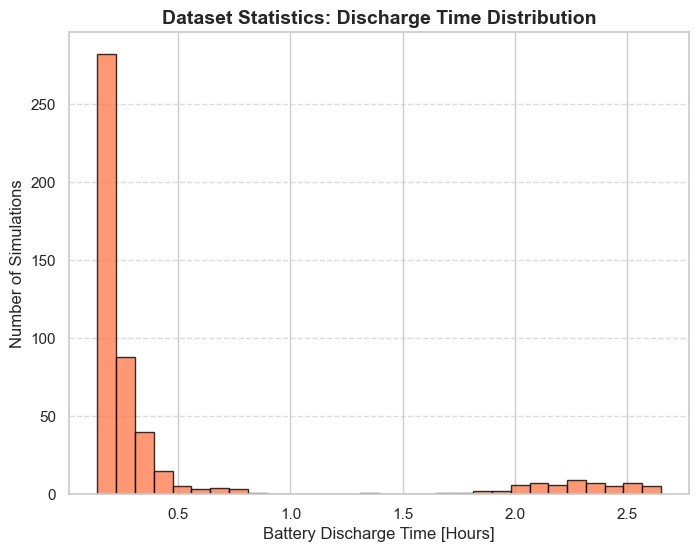

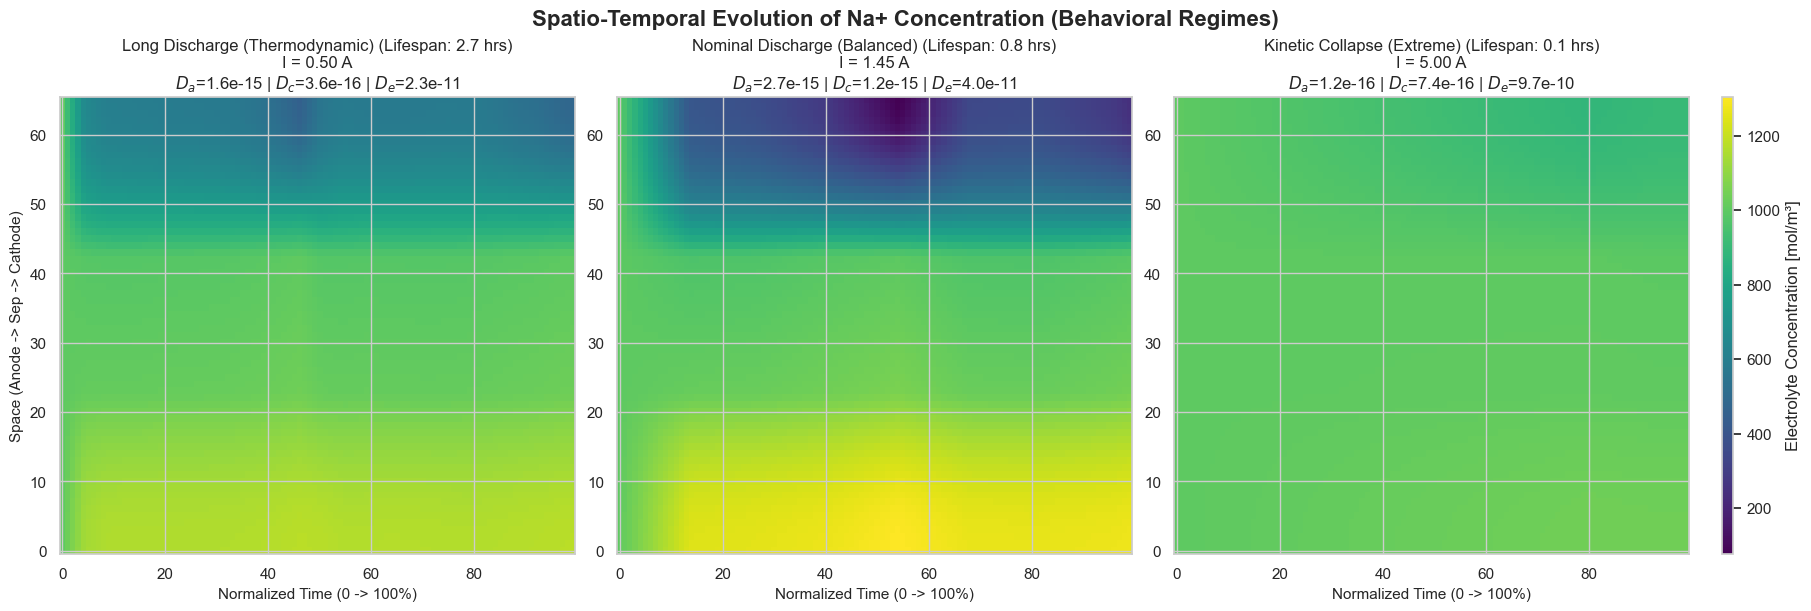

In [5]:
dataset = np.load('dataset_sodium.npz')
X = dataset['X']
Y = dataset['Y']
T_durations = dataset['T']

num_samples = X.shape[0]
currents = X[:, 0]
D_anode = X[:, 1]
D_cathode = X[:, 2]
D_electrolyte = X[:, 3]

sns.set_theme(style="whitegrid", palette="muted")

# PLOT 1: 4D PARAMETER SPACE (PAIRPLOT)
df_params = pd.DataFrame({  # apply log scale to diffusivities for better visualization
    'Current [A]': currents,
    'Log($D_{anode}$)': np.log10(D_anode),
    'Log($D_{cathode}$)': np.log10(D_cathode),
    'Log($D_{electrolyte}$)': np.log10(D_electrolyte)
})
pairplot = sns.pairplot(    # Generates a grid of scatter plots for each pair of parameters, with KDE on the diagonal
    df_params, 
    diag_kind="kde", 
    plot_kws={'alpha': 0.6, 's': 20, 'edgecolor': 'k'}
)
pairplot.figure.suptitle(f"LHS 4D Parameter Space Exploration (N={num_samples})", y=1.02, fontsize=16, fontweight='bold')
# pairplot.figure.savefig('Fig1_Pairplot.png', dpi=300, bbox_inches='tight')


# PLOT 2: STATISTICAL ANALYSIS (DISCHARGE TIME HISTOGRAM)
fig2, ax2 = plt.subplots(figsize=(8, 6))
T_hours = T_durations / 3600.0 
ax2.hist(T_hours, bins=30, color='coral', edgecolor='black', alpha=0.8)
ax2.set_title('Dataset Statistics: Discharge Time Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Battery Discharge Time [Hours]', fontsize=12)
ax2.set_ylabel('Number of Simulations', fontsize=12)
ax2.grid(True, axis='y', ls="--", alpha=0.7)
# fig2.savefig('Fig2_Histogram.png', dpi=300, bbox_inches='tight')

# PLOT 3: REPRESENTATIVE HEATMAPS
fig3, axes = plt.subplots(1, 3, figsize=(18, 6), constrained_layout=True)
idx_long = np.argmax(T_hours)
target_time = 0.9 
idx_mid = np.argmin(np.abs(T_hours - target_time))
idx_short = np.argmin(T_hours)
indices_to_show = [idx_long, idx_mid, idx_short]
titles = ['Long Discharge (Thermodynamic)', 'Nominal Discharge (Balanced)', 'Kinetic Collapse (Extreme)']

# global vmin and vmax for consistent color scaling
vmin = np.min(Y[indices_to_show])
vmax = np.max(Y[indices_to_show])

for i, idx in enumerate(indices_to_show):
    ax = axes[i]
    im = ax.imshow(Y[idx], aspect='auto', cmap='viridis', origin='lower', vmin=vmin, vmax=vmax)
    
    val_I = X[idx, 0]
    val_Da = X[idx, 1]
    val_Dc = X[idx, 2]
    val_De = X[idx, 3]
    time_h = T_hours[idx]
    
    # Title showing exact parameters
    fullTitle = (
        f"{titles[i]} (Lifespan: {time_h:.1f} hrs)\n"
        f"I = {val_I:.2f} A\n"
        f"$D_a$={val_Da:.1e} | $D_c$={val_Dc:.1e} | $D_e$={val_De:.1e}"
    )
    ax.set_title(fullTitle, fontsize=12)
    ax.set_xlabel('Normalized Time (0 -> 100%)', fontsize=11)
    
    if i == 0:
        ax.set_ylabel('Space (Anode -> Sep -> Cathode)', fontsize=11)

# Colorbar
cbar = fig3.colorbar(im, ax=axes, pad=0.02, aspect=40)
cbar.set_label('Electrolyte Concentration [mol/m³]', fontsize=12)

fig3.suptitle('Spatio-Temporal Evolution of Na+ Concentration (Behavioral Regimes)', fontsize=16, fontweight='bold')

# fig3.savefig('Fig3_Heatmaps.png', dpi=300, bbox_inches='tight')

plt.show()